In [19]:
import pandas as pd
from input_management import DatasetMapper
import numpy as np
from datetime import timedelta
data = pd.read_excel("../../../data/online+retail/Online_retail.xlsx")

data = data.dropna()
data.reset_index(inplace=True)
data.head(5)

,index,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [20]:
data['total'] = data['Quantity']*data['UnitPrice']

mapper = DatasetMapper()
data_clean = mapper.transform(data)

data_clean.head(5)

Mapeo automático:
  id_usuario <- CustomerID (confianza: 1.00)
  total_pedido <- total (confianza: 1.00)
  fecha_pedido <- InvoiceDate (confianza: 0.90)
  id_pedido <- InvoiceNo (confianza: 0.84)


,id_usuario,total_pedido,fecha_pedido,id_pedido
0,17850.0,15.30,2010-12-01 08:26:00,536365
1,17850.0,20.34,2010-12-01 08:26:00,536365
2,17850.0,22.00,2010-12-01 08:26:00,536365
3,17850.0,20.34,2010-12-01 08:26:00,536365
4,17850.0,20.34,2010-12-01 08:26:00,536365


In [21]:
data_clean["id_usuario"] = data_clean["id_usuario"].astype(float).astype(int)

In [22]:
df_consolidado = data_clean.groupby(['id_usuario', 'id_pedido', 'fecha_pedido']).agg({'total_pedido': 'sum'}).reset_index()

In [23]:
frecuencia = '14D'
fecha_max = data_clean["fecha_pedido"].max()
fecha_min = data_clean["fecha_pedido"].min()

In [24]:
def LRFM_calculation(grupo_cliente_bloque, fecha_fin_bloque, P=1):
    if grupo_cliente_bloque.empty:
        return [0,0,0,0]
    
    #L -> LENGTH, es calcular el tiempo desde la primera a la última transacción en el bloque
    first_i = grupo_cliente_bloque["fecha_pedido"].min()
    last_i1 = grupo_cliente_bloque["fecha_pedido"].max()
    L=(last_i1 - first_i).days

    #R -> RECENCY, promedio de tiempo a las últimas P transacciones
    #Me fatla probar con otros valores pero en dos semanas es raro que se hagan más pedidos
    # P=1
    recent_transactios = grupo_cliente_bloque.sort_values('fecha_pedido',ascending = False).head(P)
    R_prima = (fecha_fin_bloque - recent_transactios['fecha_pedido']).dt.total_seconds().mean() / (3600*24)

    #F -> Frecuencia, el numero de transacciones
    F = grupo_cliente_bloque['id_pedido'].nunique()

    #M -> Monetary, total de lo gastado por el cliente en este tiempo
    M = grupo_cliente_bloque['total_pedido'].sum()

    return [L,R_prima, F, M]

In [25]:
clients = df_consolidado['id_usuario'].unique()
intervalos = pd.date_range(start=fecha_min, end=fecha_max + timedelta(days=14), freq=frecuencia)

mts_resultados = {}

for cliente in clients:
    serie_cliente = []
    df_cliente =df_consolidado[df_consolidado['id_usuario']==cliente]

    for i in range(len(intervalos)-1):
        inicio, fin = intervalos[i], intervalos[i+1]
        mask = (df_cliente['fecha_pedido'] >= inicio) & (df_cliente['fecha_pedido'] < fin)
        metricas = LRFM_calculation(df_cliente[mask], fin)
        serie_cliente.append(metricas)

    mts_resultados[cliente] = np.array(serie_cliente)

print(f"Procesado: {len(mts_resultados)} clientes.")


Procesado: 4372 clientes.


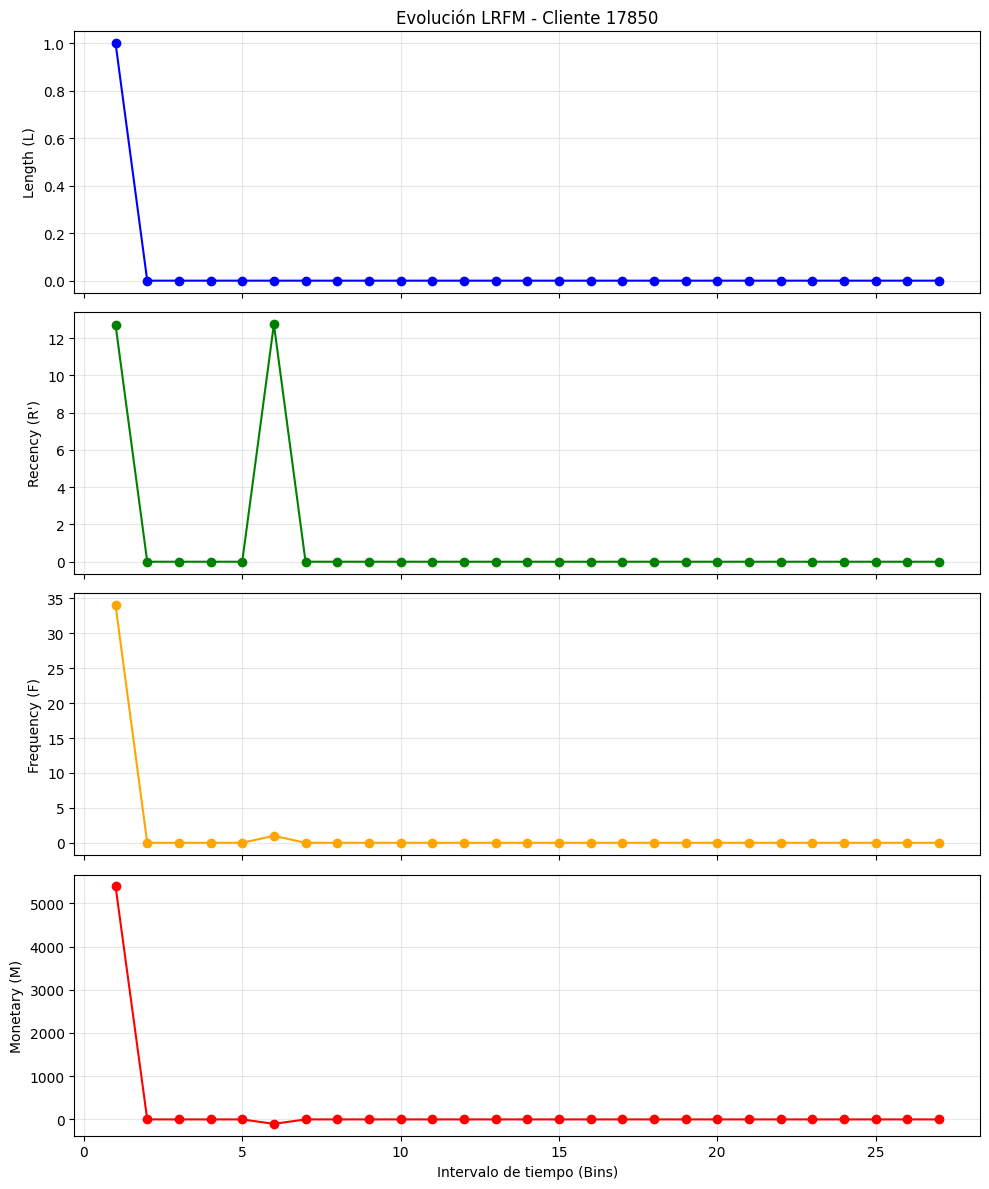

In [26]:
import matplotlib.pyplot as plt

def plot_cliente(id_cliente, matrices_mts):
    data = matrices_mts[id_cliente]
    pasos_tiempo = range(1, len(data) + 1)
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
    nombres = ['Length (L)', "Recency (R')", 'Frequency (F)', 'Monetary (M)']
    colores = ['blue', 'green', 'orange', 'red']
    
    for i in range(4):
        axes[i].plot(pasos_tiempo, data[:, i], marker='o', color=colores[i])
        axes[i].set_ylabel(nombres[i])
        axes[i].grid(True, alpha=0.3)
        if i == 0:
            axes[i].set_title(f"Evolución LRFM - Cliente {id_cliente}")
            
    plt.xlabel("Intervalo de tiempo (Bins)")
    plt.tight_layout()
    plt.show()

plot_cliente(17850, mts_resultados)